In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

patients = pd.read_csv("data/raw/patients.csv")
print(f"Patients loaded: {len(patients)}")  # should be ~5700, not 140

Patients loaded: 5747


In [2]:
HYPERTENSION_CODE = 59621000
AFIB_CODE = 49436004
DIABETES_CODE = 44054006
STROKE_CODE = 230690007

conditions = pd.read_csv("data/raw/conditions.csv", parse_dates=["START"])
encounters = pd.read_csv("data/raw/encounters.csv", parse_dates=["START"])
medications = pd.read_csv("data/raw/medications.csv", parse_dates=["START"])
patients = pd.read_csv("data/raw/patients.csv", parse_dates=["BIRTHDATE", "DEATHDATE"])

# normalize timezones across all date columns immediately, before anything uses them
def make_tz_naive(series):
    series = pd.to_datetime(series)
    if getattr(series.dt, "tz", None) is not None:
        series = series.dt.tz_localize(None)
    return series

for df, col in [(conditions, "START"), (encounters, "START"), (medications, "START"),
                 (patients, "BIRTHDATE"), (patients, "DEATHDATE")]:
    df[col] = make_tz_naive(df[col])

print(f"Patients: {len(patients)}, Conditions: {len(conditions)}, "
      f"Encounters: {len(encounters)}, Medications: {len(medications)}")

Patients: 5747, Conditions: 207846, Encounters: 341236, Medications: 289944


In [3]:
# ============================================================
# CELL 3: Cohort + label definition (leakage-safe cutoff dates)
# ============================================================
import numpy as np
np.random.seed(42)

# Find every stroke diagnosis, keep the FIRST one per patient
stroke_dx = conditions[conditions["CODE"] == STROKE_CODE].copy()
first_stroke = (
    stroke_dx.sort_values("START")
    .groupby("PATIENT", as_index=False)
    .first()[["PATIENT", "START"]]
    .rename(columns={"PATIENT": "patient_id", "START": "cutoff_date"})
)
first_stroke["label"] = 1

# Everyone else is a control candidate - assign a random cutoff from their own history
case_ids = set(first_stroke["patient_id"])
control_ids = patients[~patients["Id"].isin(case_ids)]["Id"]
enc_by_patient = encounters.groupby("PATIENT")["START"]

control_rows = []
for pid in control_ids:
    if pid not in enc_by_patient.groups:
        continue
    dates = enc_by_patient.get_group(pid)
    chosen = dates.sample(1, random_state=hash(pid) % (2**32)).iloc[0]
    control_rows.append({"patient_id": pid, "cutoff_date": chosen, "label": 0})

controls = pd.DataFrame(control_rows)

cohort = pd.concat([first_stroke, controls], ignore_index=True)
cohort = cohort.merge(patients[["Id", "BIRTHDATE", "DEATHDATE", "GENDER"]],
                       left_on="patient_id", right_on="Id", how="left").drop(columns="Id")
cohort = cohort[cohort["cutoff_date"] > cohort["BIRTHDATE"]]

print(f"Final cohort: {len(cohort)} patients "
      f"({cohort['label'].sum()} cases, {(cohort['label']==0).sum()} controls, "
      f"{cohort['label'].mean():.1%} positive)")

Final cohort: 5747 patients (40 cases, 5707 controls, 0.7% positive)


In [4]:
# ============================================================
# CELL 4: Feature engineering
# ============================================================
cohort['age_at_cutoff'] = (cohort['cutoff_date'] - cohort['BIRTHDATE']).dt.days / 365.25

def add_condition_flag(cohort, conditions, code, column_name):
    merged = conditions.merge(cohort[['patient_id', 'cutoff_date']],
                               left_on='PATIENT', right_on='patient_id', how='inner')
    matches = merged[(merged['CODE'] == code) & (merged['START'] < merged['cutoff_date'])]
    positive_patients = set(matches['patient_id'].unique())
    if column_name in cohort.columns:
        cohort = cohort.drop(columns=column_name)
    cohort[column_name] = cohort['patient_id'].isin(positive_patients).astype(int)
    return cohort

cohort = add_condition_flag(cohort, conditions, HYPERTENSION_CODE, 'has_hypertension')
cohort = add_condition_flag(cohort, conditions, AFIB_CODE, 'has_afib')
cohort = add_condition_flag(cohort, conditions, DIABETES_CODE, 'has_diabetes')

def count_events_before_cutoff(cohort, events_df, column_name):
    merged = events_df.merge(cohort[['patient_id', 'cutoff_date']],
                              left_on='PATIENT', right_on='patient_id', how='inner')
    before_cutoff = merged[merged['START'] < merged['cutoff_date']]
    counts = before_cutoff.groupby('patient_id').size().rename(column_name)
    if column_name in cohort.columns:
        cohort = cohort.drop(columns=column_name)
    cohort = cohort.merge(counts, on='patient_id', how='left')
    cohort[column_name] = cohort[column_name].fillna(0).astype(int)
    return cohort

cohort = count_events_before_cutoff(cohort, conditions, 'n_conditions_total')
cohort = count_events_before_cutoff(cohort, medications, 'n_medications_total')

print(cohort.groupby('label')[['age_at_cutoff', 'has_hypertension', 'has_afib',
                                 'has_diabetes', 'n_conditions_total',
                                 'n_medications_total']].mean())

       age_at_cutoff  has_hypertension  has_afib  has_diabetes  \
label                                                            
0          34.958693          0.182057   0.00403       0.05905   
1          63.943806          0.550000   0.07500       0.15000   

       n_conditions_total  n_medications_total  
label                                           
0               20.048712            23.181006  
1               36.050000            32.150000  


In [5]:
# ============================================================
# CELL 5: Save features, then train/test split
# ============================================================
cohort.to_csv("data/processed/features.csv", index=False)

from sklearn.model_selection import train_test_split

y = cohort['label']
X = cohort.drop(columns=['patient_id', 'cutoff_date', 'label', 'BIRTHDATE', 'DEATHDATE', 'GENDER'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} patients, {y_train.sum()} stroke cases ({y_train.mean():.1%})")
print(f"Test:  {X_test.shape[0]} patients, {y_test.sum()} stroke cases ({y_test.mean():.1%})")

Train: 4597 patients, 32 stroke cases (0.7%)
Test:  1150 patients, 8 stroke cases (0.7%)


In [6]:
# ============================================================
# CELL 6: Train + evaluate baseline logistic regression
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature:25s} {coef:+.4f}")

y_pred_proba = model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_pred_proba):.3f}\n")
print(classification_report(y_test, model.predict(X_test), target_names=['No Stroke', 'Stroke']))

Coefficients:
  age_at_cutoff             +0.0537
  has_hypertension          +1.2917
  has_afib                  +1.7957
  has_diabetes              -0.5199
  n_conditions_total        +0.0408
  n_medications_total       -0.0213

ROC-AUC: 0.862
PR-AUC:  0.106

              precision    recall  f1-score   support

   No Stroke       1.00      0.77      0.87      1142
      Stroke       0.02      0.62      0.04         8

    accuracy                           0.77      1150
   macro avg       0.51      0.70      0.45      1150
weighted avg       0.99      0.77      0.86      1150



In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
pr_auc_scores = cross_val_score(model, X, y, cv=cv, scoring='average_precision')

print(f"ROC-AUC:  {roc_auc_scores.mean():.3f} ± {roc_auc_scores.std():.3f}")
print(f"PR-AUC:   {pr_auc_scores.mean():.3f} ± {pr_auc_scores.std():.3f}")
print(f"\nPer-fold ROC-AUC: {[round(s, 3) for s in roc_auc_scores]}")
print(f"Per-fold PR-AUC:  {[round(s, 3) for s in pr_auc_scores]}")

ROC-AUC:  0.858 ± 0.026
PR-AUC:   0.093 ± 0.073

Per-fold ROC-AUC: [np.float64(0.826), np.float64(0.888), np.float64(0.888), np.float64(0.846), np.float64(0.84)]
Per-fold PR-AUC:  [np.float64(0.232), np.float64(0.091), np.float64(0.06), np.float64(0.025), np.float64(0.056)]


In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# scale_pos_weight is XGBoost's version of class_weight='balanced' -
# standard formula: (# negative / # positive)
n_pos = y.sum()
n_neg = len(y) - n_pos
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.1f} ({n_neg} controls / {n_pos} cases)")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,          # shallow trees - with only 40 positive cases,
                           # deep trees would just memorize individual patients
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_roc_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')
xgb_pr_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='average_precision')

print(f"\nXGBoost  ROC-AUC: {xgb_roc_scores.mean():.3f} ± {xgb_roc_scores.std():.3f}")
print(f"XGBoost  PR-AUC:  {xgb_pr_scores.mean():.3f} ± {xgb_pr_scores.std():.3f}")

print(f"\n--- Comparison ---")
print(f"Logistic Regression  ROC-AUC: 0.858 ± 0.026   PR-AUC: 0.093 ± 0.073")
print(f"XGBoost              ROC-AUC: {xgb_roc_scores.mean():.3f} ± {xgb_roc_scores.std():.3f}   "
      f"PR-AUC: {xgb_pr_scores.mean():.3f} ± {xgb_pr_scores.std():.3f}")

scale_pos_weight = 142.7 (5707 controls / 40 cases)

XGBoost  ROC-AUC: 0.819 ± 0.027
XGBoost  PR-AUC:  0.037 ± 0.013

--- Comparison ---
Logistic Regression  ROC-AUC: 0.858 ± 0.026   PR-AUC: 0.093 ± 0.073
XGBoost              ROC-AUC: 0.819 ± 0.027   PR-AUC: 0.037 ± 0.013


Background dataset has 5747 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5747 when initializing the masker.
C:\Users\igbid\AppData\Local\Temp\ipykernel_9140\2353524947.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=True)


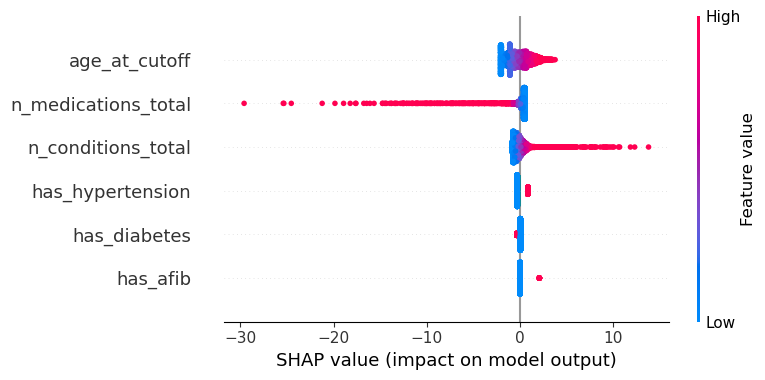

In [9]:
import shap

# Fit the final model on ALL the data (not just one CV fold) - since
# this is now for explanation/deployment, not evaluation, we want the
# model trained on everything we have available.
final_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
final_model.fit(X, y)

# LinearExplainer is the right SHAP explainer for logistic regression
# specifically (tree models use a different one - TreeExplainer)
explainer = shap.LinearExplainer(final_model, X)
shap_values = explainer(X)

# Summary plot: shows which features matter most OVERALL, and whether
# high or low values of that feature push risk up or down
shap.summary_plot(shap_values, X, show=True)

Background dataset has 5747 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5747 when initializing the masker.


Coefficients (on standardized features - now comparable across features):
  n_medications_total       -1.7818
  age_at_cutoff             +1.2604
  n_conditions_total        +1.0334
  has_hypertension          +0.4458
  has_afib                  +0.1518
  has_diabetes              -0.0953


C:\Users\igbid\AppData\Local\Temp\ipykernel_9140\2827506183.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_scaled, X_scaled, show=True)


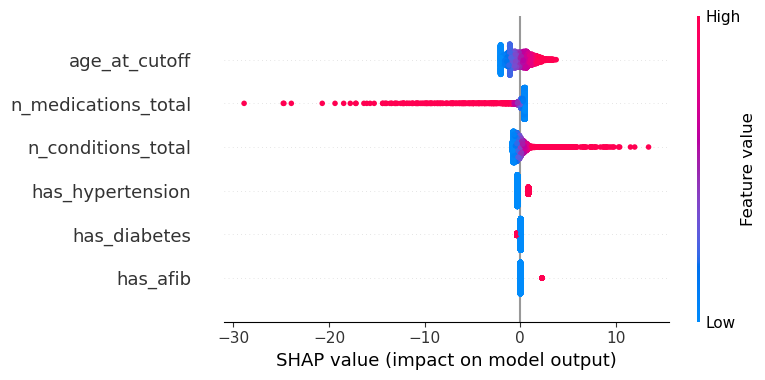

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

final_model_scaled = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
final_model_scaled.fit(X_scaled, y)

print("Coefficients (on standardized features - now comparable across features):")
for feature, coef in sorted(zip(X.columns, final_model_scaled.coef_[0]),
                              key=lambda pair: -abs(pair[1])):
    print(f"  {feature:25s} {coef:+.4f}")

explainer_scaled = shap.LinearExplainer(final_model_scaled, X_scaled)
shap_values_scaled = explainer_scaled(X_scaled)

shap.summary_plot(shap_values_scaled, X_scaled, show=True)

In [11]:
def compute_simplified_cha2ds2vasc(row):
    score = 0
    if row['age_at_cutoff'] >= 75:
        score += 2
    elif row['age_at_cutoff'] >= 65:
        score += 1
    if row['has_hypertension'] == 1:
        score += 1
    if row['has_diabetes'] == 1:
        score += 1
    if row['GENDER'] == 'F':
        score += 1
    return score

cohort['clinical_score'] = cohort.apply(compute_simplified_cha2ds2vasc, axis=1)

from sklearn.metrics import roc_auc_score, average_precision_score

clinical_roc_auc = roc_auc_score(cohort['label'], cohort['clinical_score'])
clinical_pr_auc = average_precision_score(cohort['label'], cohort['clinical_score'])

print("Simplified CHA2DS2-VASc-style score:")
print(f"  ROC-AUC: {clinical_roc_auc:.3f}")
print(f"  PR-AUC:  {clinical_pr_auc:.3f}")
print()
print("Your logistic regression model (from cross-validation):")
print(f"  ROC-AUC: 0.858 ± 0.026")
print(f"  PR-AUC:  0.093 ± 0.073")
print()
print(cohort.groupby('label')['clinical_score'].mean())

Simplified CHA2DS2-VASc-style score:
  ROC-AUC: 0.754
  PR-AUC:  0.024

Your logistic regression model (from cross-validation):
  ROC-AUC: 0.858 ± 0.026
  PR-AUC:  0.093 ± 0.073

label
0    0.912213
1    2.025000
Name: clinical_score, dtype: float64


In [12]:
import joblib

joblib.dump(final_model_scaled, "data/processed/stroke_model.pkl")
joblib.dump(scaler, "data/processed/feature_scaler.pkl")

# Save feature stats too - the app will need reasonable min/max/default
# values for each input slider
feature_stats = X.describe()
feature_stats.to_csv("data/processed/feature_stats.csv")

print("Model, scaler, and feature stats saved.")

Model, scaler, and feature stats saved.


In [13]:
background_sample = X_scaled.sample(n=min(200, len(X_scaled)), random_state=42)
background_sample.to_csv("data/processed/shap_background.csv", index=False)
print(f"Saved background sample: {background_sample.shape}")

Saved background sample: (200, 6)
